In [7]:
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import spacy
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

nlp = spacy.load("ru_core_news_md")

RANDOM_SEED = 42

# Линейные и метрические модели

В этом ноутбуке будут рассмотрены две модели: логистическая регрессия и KNN, а также два подхода к извлечению признаков - Bag of words (BoW) и модификация BoW при помощи PCA для уменьшения размерности признакового пространства. Для сравнения моделей выбраны две метрики PR-AUC и F1-macro.

## Загрузка данных и вспомогательные функции

С учетом дизбаланса классов, было выполнено стратифицированное разделение на трейн и тест, размер тестовой выборки 20% от исходного размера датасета.

In [2]:
df = pd.read_csv('../data/interim/cleaned_comments.csv')
X = df['comment']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

In [3]:
allowed_punct = {'!', '?'}
TOKEN_PATTERN = r'[а-яё]+|[!?]|[\U0001F300-\U0001FAFF\U0001F1E6-\U0001F1FF]'

# дополнительная лемматизация слов, чтобы уменьшить размер словаря для BoW
def clean_lemmatize_comment(comment: str) -> str:
    cleaned = []
    for token in nlp(comment):
        if token.is_stop:
            continue
        if token.is_alpha:
            lemma = token.lemma_
            if len(lemma) < 3 or len(lemma) > 30:
                continue
            else:
                cleaned.append(lemma)
        elif token.is_punct:
            if token.text in allowed_punct:
                cleaned.append(token.text)
        else:
            cleaned.append(token.text)
    return ' '.join(cleaned)

class LabelEncoderClassifier(BaseEstimator, ClassifierMixin):
    """
    Обертка над классификатором, которая кодирует строковые лэйблы
    классов в числовые перед fit и после predict.
    """
    def __init__(self, classifier):
        self.clf_ = classifier
        self.encoder_ = LabelEncoder()

    def fit(self, X, y):
        y_encoded = self.encoder_.fit_transform(y)
        self.clf_.fit(X, y_encoded)

        return self

    def predict(self, X):
        return self.encoder_.inverse_transform(self.clf_.predict(X))

    def predict_proba(self, X):
        return self.clf_.predict_proba(X)

    def coef(self):
        return self.clf_.coef_

    def classes(self):
        return self.encoder_.classes_

class SVDVectorizer(BaseEstimator, TransformerMixin):
    """
    Трансформер, выполняющий SVD для матрицы X, где каждая строка
    соответствует комментарию, а каждый столбец частоте слова в комментариях
    """
    def __init__(self, n_components=2, random_seed=None):
        self.n_components = n_components
        self.random_seed = random_seed
        self.vectorizer_ = None
        self.svd_ = None

    def fit(self, X, y=None):
        self.vectorizer_ = TfidfVectorizer(token_pattern=TOKEN_PATTERN)
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=self.random_seed)
        self.svd_.fit(self.vectorizer_.fit_transform(X))
        return self

    def transform(self, X):
        return self.svd_.transform(self.vectorizer_.transform(X))


Следующая ячейка выполняет лемматизацию датасета, выполняется довольно долго, результат в pickle-формате можно загрузить через dvc.

In [4]:
# X_train = X_train.apply(clean_lemmatize_comment)
# X_test = X_test.apply(clean_lemmatize_comment)
#
# with open('./../data/interim/X_train.pkl', 'wb') as file:
#     pickle.dump(X_train, file)
# with open('./../data/interim/X_test.pkl', 'wb') as file:
#     pickle.dump(X_test, file)

In [4]:
with open('./../data/interim/X_train.pkl', 'rb') as file:
    X_train = pickle.load(file)
with open('./../data/interim/X_test.pkl', 'rb') as file:
    X_test = pickle.load(file)

## Обучение моделей и подбор параметров

Подберем оптимальные параметры для логистической регрессии с помощью кросс-валидации:

* `vectorizer__max_features` - размер словаря. Сравним два подхода с ограничением количество слов и без, `CountVectorizer` позволяет указать какое количество слов, отсортированных по убыванию встречаемости, попадет в итоговый словарь.
* `logreg__C` - параметр регуляризации. Так как частоты слов не нормируются, получившаяся матрица объекты-признаки может получиться плохо обусловленной, регуляризация поможет это обойти.

In [15]:
label_encoder = LabelEncoder()
logreg_bow = Pipeline([
    ('vectorizer', CountVectorizer(token_pattern=TOKEN_PATTERN)),
    ('logreg', LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l2'))
])

gc_params = {
    'logreg__C': [1, 0.5, 0.1],
    'vectorizer__max_features': [None, 1000, 10_000, 50_000, 100_000],
}

skf = StratifiedKFold(n_splits=3)

gc = GridSearchCV(logreg_bow, gc_params, scoring='f1_macro', cv=skf, verbose=True, n_jobs=-1)

gc = gc.fit(X_train, label_encoder.fit_transform(y_train))

gc_results = pd.DataFrame(gc.cv_results_)
cols = [c for c in gc_results.columns if c.startswith('param_')]
cols.append('mean_test_score')

gc_results[cols].sort_values(by='mean_test_score', ascending=False)
best_estimator = gc.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits


In [16]:
gc_results[cols].sort_values(by='mean_test_score', ascending=False)

,param_logreg__C,param_vectorizer__max_features,mean_test_score
0,1.0,None,0.818916
4,1.0,100000,0.817985
5,0.5,None,0.816237
9,0.5,100000,0.815510
8,0.5,50000,0.806271
3,1.0,50000,0.805850
10,0.1,None,0.799582
14,0.1,100000,0.798812
13,0.1,50000,0.794303
12,0.1,10000,0.764553


Лучше всего себя показывает модель на всех словах датасета без регуляризации. Для линейной модели и такого примитивного метода векторизации текста, который не учитывает контекст и порядок слов, качество по f1 macro довольно высокое `0.81`. Cкорее всего это связано с тем, что в данном датасете каждый класс токсичности практически однозначно определяется набором лексики, характерным для этого класса (оскорбления, угрозы, непристойные предложения).

Посмотрим, каким словам модель дала наиболее высокие веса, в зависимости от класса:

In [17]:
def print_features(vocab, weights, classes):
    print(f'Vocab size: {len(vocab)}')
    big_weights = (-weights).argsort(axis=1)
    print(f'Features with biggest weights by class:')
    for i, class_name in enumerate(classes):
        print(f'[{class_name}]')
        for j in range(3):
            print(f'\tfeature: {vocab[big_weights[i][j]]}, weight: {big_weights[i][j]}')

print_features(best_estimator['vectorizer'].get_feature_names_out(), best_estimator['logreg'].coef_, label_encoder.classes_)

Vocab size: 143944
Features with biggest weights by class:
[INSULT]
	feature: пиздобол, weight: 85232
	feature: долбоеб, weight: 29008
	feature: выблядки, weight: 18227
[NORMAL]
	feature: кпсс, weight: 51427
	feature: здравствовать, weight: 39451
	feature: красота, weight: 51772
[OBSCENITY]
	feature: трахать, weight: 125362
	feature: отсосать, weight: 79549
	feature: трахнуть, weight: 125393
[THREAT]
	feature: расстрелять, weight: 104921
	feature: растрелять, weight: 105135
	feature: расстреливать, weight: 104906


В целом, найденные слова иллюстрируют предположение выше. Всего модель содержит 143944 весов, причем большая часть из них нулевые, так как большинство слов в отрыве от контекста несут мало инфомации о тональности всего высказывания, рассмотрим распределение весов:

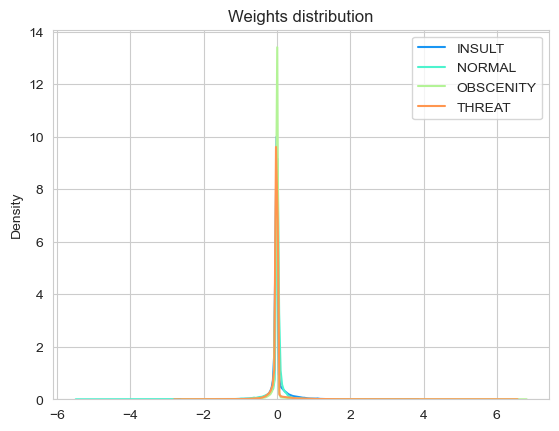

In [18]:
n_classes = label_encoder.classes_
weights = best_estimator['logreg'].coef_.copy()
colors = sns.color_palette('rainbow', n_classes.shape[0])
with sns.axes_style('whitegrid'):
    for i in range(n_classes.shape[0]):
        ax = sns.kdeplot(weights[i, :], label=n_classes[i], color=colors[i])
    ax.set_title('Weights distribution')
    ax.legend().get_frame().set_facecolor("white")
plt.show()

Подавляющее количество слов не несут ни какой информации для модели о классе комментария, попробуем сжать признаковое пространство таким образом, чтобы избавиться от необходимости хранить каждое слово, вместе с тем сохранить информацию о тональности комментария.

Для этого воспользуемся методом PCA: первые $k$ векторов матрицы V из SVD разложения для X будут соответствовать направлениям, вдоль которых объекты (комментарии) имеют наибольшую вариативность. Так как в BoW каждый комментарий закодирован точкой в пространстве, где каждый базисный вектор соответствуют определенному слову, направления наибольшей вариативности - это линейные комбинации векторов-слов. Выполним TruncatedSVD для матрицы и посмотрим, какие направления это преобразование ищет:

In [9]:
k = 500
transformer = SVDVectorizer(n_components=k, random_seed=RANDOM_SEED)
transformer = transformer.fit(X_train)
V = transformer.svd_.components_.copy() # матрица (vocabulary size) x k, соответствует правым сингулярным векторам
vocab = transformer.vectorizer_.get_feature_names_out()
for i in range(k):
    print(f'Direction {i + 1}')
    max_coord = (-np.abs(V[i])).argsort()
    min_coord = np.abs(V[i]).argmin()
    print(f'\t{vocab[max_coord[0]]}, {vocab[max_coord[1]]}, {vocab[max_coord[2]]}, {vocab[max_coord[3]]}')

Direction 1
	!, ?, 👍, молодец
Direction 2
	?, !, цена, здравствовать
Direction 3
	👍, молодец, 👏, !
Direction 4
	спасибо, здоровье, человек, хороший
Direction 5
	спасибо, 😂, здоровье, большой
Direction 6
	😂, спасибо, здоровье, бог
Direction 7
	человек, здоровье, хороший, спасибо
Direction 8
	здравствовать, цена, человек, день
Direction 9
	добрый, день, молодец, здравствовать
Direction 10
	хороший, молодец, год, красивый
Direction 11
	хороший, год, молодец, человек
Direction 12
	красивый, год, молодец, здравствовать
Direction 13
	красивый, молодец, год, человек
Direction 14
	цена, здравствовать, день, какой
Direction 15
	ребёнок, 🙏, человек, год
Direction 16
	🙏, ребёнок, год, сказать
Direction 17
	🙏, бог, дать, добрый
Direction 18
	сказать, ребёнок, знать, пидор
Direction 19
	знать, сказать, ребёнок, пидор
Direction 20
	пидор, знать, тварь, 👎
Direction 21
	делать, знать, вкусный, пидор
Direction 22
	написать, номер, знать, делать
Direction 23
	день, добрый, написать, бог
Direction 24
	кл

Попробуем перейти из признакового пространства слов в признаковое пространство этих направлений, а затем снова обучить логистическую регрессию. Размерность пространства подберем через кросс-валидацию.

In [10]:
label_encoder = LabelEncoder()
svd_logreg = Pipeline([
    ('smart_vec', SVDVectorizer(random_seed=RANDOM_SEED)),
    ('logreg', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

gc_params = {
    'smart_vec__n_components': [5, 10, 20, 50, 100, 500],
}
skf = StratifiedKFold(n_splits=3)
gc = GridSearchCV(svd_logreg, gc_params, scoring='f1_macro', cv=skf, verbose=True, n_jobs=-1)

gc = gc.fit(X_train, label_encoder.fit_transform(y_train))

gc_results = pd.DataFrame(gc.cv_results_)
cols = [c for c in gc_results.columns if c.startswith('param_')]
cols.append('mean_test_score')

gc_results[cols].sort_values(by='mean_test_score', ascending=False)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,param_smart_vec__n_components,mean_test_score
5,500,0.574217
4,100,0.410874
3,50,0.365541
2,20,0.288235
1,10,0.239242
0,5,0.194692


Результаты хуже, чем у логистической регрессии на всех словах. Это ожидаемо, ведь мы теряем информацию о наличии определенных слов в каждом комментарии. Также, возможно в новом пространстве невозможно хорошо линейно разделить классы комментариев, поэтому попробуем другие модели.

Для нового признакового пространства также можно попробовать обучить метрическую модель. Для исходного пространства в 150.000 признаков KNN работал бы плохо, так как в таких пространствах большой размерности расстояния перестают быть информативными. По кросс-валидации подберем следующие параметры:

* `n_neighbors` - количество соседей для построения оценки принадлежности к классу
* `n_components` - размерность признакового пространства

In [6]:
label_encoder = LabelEncoder()
svd_knn = Pipeline([
    ('smart_vec', SVDVectorizer(n_components=7, random_seed=RANDOM_SEED)),
    ('knn', KNeighborsClassifier(weights='distance', metric='euclidean'))
])

gc_params = {
    'knn__n_neighbors': [40, 80, 160],
    'smart_vec__n_components': [100, 200, 400],
}

skf = StratifiedKFold(n_splits=3)
gc = GridSearchCV(svd_knn, gc_params, scoring='f1_macro', cv=skf, verbose=True)

gc = gc.fit(X_train, label_encoder.fit_transform(y_train))

gc_results = pd.DataFrame(gc.cv_results_)
cols = [c for c in gc_results.columns if c.startswith('param_')]
cols.append('mean_test_score')

print(f'Top parameters:')
gc_results[cols].sort_values(by='mean_test_score', ascending=False)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Top parameters:


,param_knn__n_neighbors,param_smart_vec__n_components,mean_test_score
2,40,400,0.579049
5,80,400,0.560393
1,40,200,0.549888
0,40,100,0.534076
4,80,200,0.531100
8,160,400,0.522821
3,80,100,0.515429
7,160,200,0.509665
6,160,100,0.497130


KNN в новом пространстве показал себя чуть лучше, чем логистическая регрессия. Но все равно уступает по качеству логистической регрессии на всех словах. Возможно, комментарии в новых координатах в целом хуже разделимы и нужно пробовать более сложные способы векторизации.

Ради интереса, посмотрим как справится KNN на исходных признаках. Ограничим количество слов в словаре, чтобы KNN мог посчитать информативные расстояния.

In [8]:
label_encoder = LabelEncoder()
bow_knn = Pipeline([
    ('vectorizer', CountVectorizer(max_features=1000, token_pattern=TOKEN_PATTERN)),
    ('knn', KNeighborsClassifier(weights='distance'))
])

gc_params = {
    'knn__n_neighbors': [5, 10, 100, 500]
}

skf = StratifiedKFold(n_splits=3)
gc = GridSearchCV(bow_knn, gc_params, scoring='f1_macro', cv=skf, verbose=True)

gc = gc.fit(X_train, label_encoder.fit_transform(y_train))

gc_results = pd.DataFrame(gc.cv_results_)
cols = [c for c in gc_results.columns if c.startswith('param_')]
cols.append('mean_test_score')

gc_results[cols].sort_values(by='mean_test_score', ascending=False)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


,param_knn__n_neighbors,mean_test_score
0,5,0.501141
1,10,0.493338
2,100,0.451077
3,500,0.397247


Результаты получились хуже, чем у knn + svd на меньшем количестве признаков.

## Сравнение метрик на тесте

Сравним все полученные модели на тесте, построим для них график PR-AUC по классам, а также посчитаем финальный f1 macro.

In [9]:
bow_logreg = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('logreg', LabelEncoderClassifier(LogisticRegression(max_iter=2000, class_weight='balanced')))
])

svd_logreg = Pipeline([
    ('smart_vec', SVDVectorizer(random_seed=RANDOM_SEED, n_components=500)),
    ('logreg', LabelEncoderClassifier(LogisticRegression(max_iter=2000, class_weight='balanced')))
])

svd_knn = Pipeline([
    ('smart_vec', SVDVectorizer(n_components=400, random_seed=RANDOM_SEED)),
    ('knn', LabelEncoderClassifier(KNeighborsClassifier(n_neighbors=40, weights='distance', metric='euclidean')))
])

bow_knn = Pipeline([
    ('vectorizer', CountVectorizer(max_features=1000)),
    ('knn', LabelEncoderClassifier(KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')))
])

models = {
    'bow_logreg': bow_logreg,
    'svd_logreg': svd_logreg,
    'svd_knn': svd_knn,
    'bow_knn': bow_knn,
}

for model in models.values():
    model.fit(X_train, y_train)

n_classes = bow_logreg['logreg'].classes()

In [10]:
results = []
for name, model in models.items():
    y_true_bin = label_binarize(y_test, classes=n_classes)
    prec, rec = {}, {}
    for i, class_name in enumerate(n_classes):
        prec[i], rec[i], _ = precision_recall_curve(y_true_bin[:, i], model.predict_proba(X_test)[:, i])
    results.append((name, prec, rec))

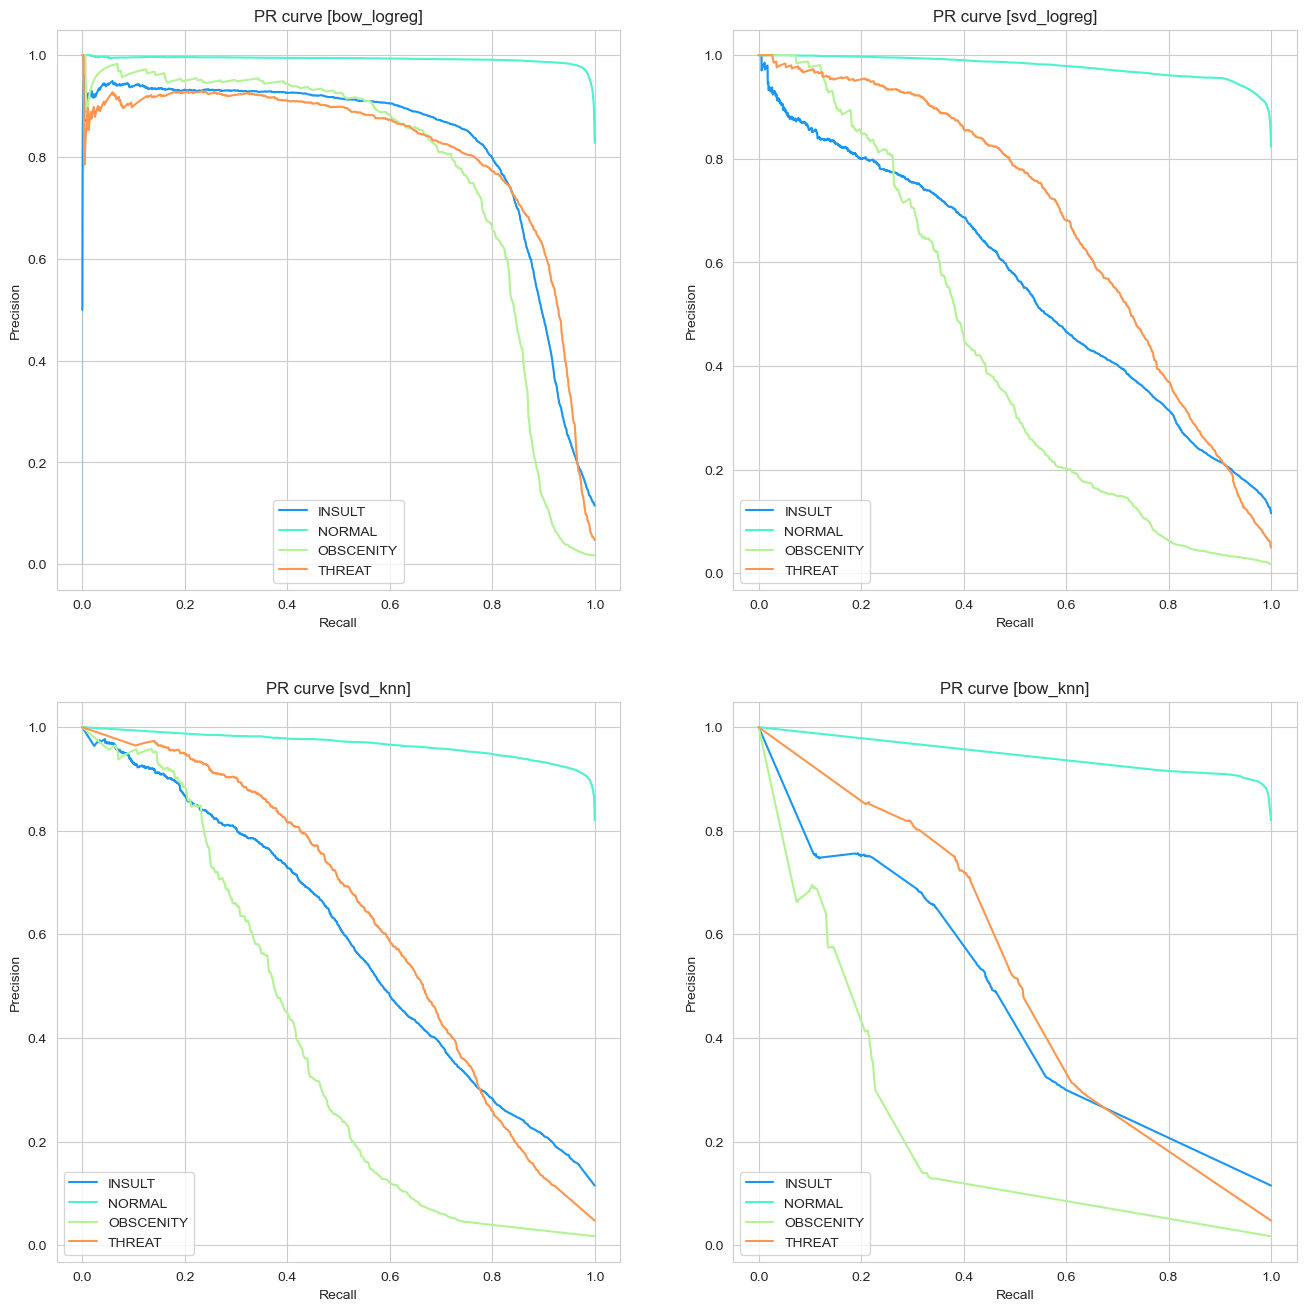

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()
for i, ax in enumerate(axes):
    name, prec, rec = results[i]
    with sns.axes_style('whitegrid'):
        for j in range(n_classes.shape[0]):
            sns.lineplot(x=rec[j], y=prec[j], label=n_classes[j], color=colors[j], ax=ax)
        ax.set_title(f'PR curve [{name}]')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
plt.show()

Графики precision-recall кривых также показывают, что логистическая регрессия + BoW лучше всего классифицирует комментарии, причем малопредставленные классы (такие как THREAT и OBSCENITY) определяются хорошо, достигая одновременно precision=0.7 и recall=0.7.

KNN и логистическая регрессия, обученные на PCA компонентах, показывают примерно одинаковое качество. Интересно, что не самый большой по размеру класс THREAT они определяют достаточно хорошо, достигая одновременно precision=0.6 и recall=0.6. А вот для самого большого токсичного класса INSULT показатели хуже, максимум precision=0.55 и recall=0.55. Самый малопредставленный класс OBSCENITY определяется плохо, причем точность падает быстрее, чем растет полнота.

Последняя модель, KNN + BoW на 1000 самых частотных слов, показывает самое плохое качество. По сути, она неплохо отличает нормальный комментарий от всех остальных, но

Построим таблицу пороговых метрик, чтобы сравнить модели для дефолтного порога 0.5

In [20]:
results = {}
label_encoder = LabelEncoder()
for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro'),
        'f1': f1_score(y_test, y_pred, average='macro'),
    }

pd.DataFrame(results)

,bow_logreg,svd_logreg,svd_knn,bow_knn
precision,0.807898,0.541915,0.794569,0.715280
recall,0.843487,0.699221,0.507046,0.472715
f1,0.824152,0.574996,0.589838,0.536873
